# Principal component analysis

> A serious attempt at all the assignments is mandatory to grant access to the final exam. Refer to the course manual for more details (section *Overview* on Brightspace). 

> Please add today's topic to your knowledge graph.

**Learning goals:**
- Be able to implement PCA;
- Understand the properties of PCA;
- Understand the limitations of PCA;
- Understand how PCA can be used for dimensionality reduction.

**Solutions file:**

For this assignment, a solutions file will be released after the deadline.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

## (Optional) Exercise 1: applications of PCA
1. Find an interesting application of PCA and post a link to it (e.g., the blog post, article, podcast, video, etc.) on the Brightspace assignment forum of Week 03. Describe the application in several sentences. As the subject of your post, use a sensible title that explains the body: i.e., use a title like `group $<$number$>$: $<$your application$>$', where you fill in your group and the application you found.
1. Try to dig deep into your application. Please answer questions that come up on the forum. We might also ask you to answer questions that come up during the flipped-classroom session.
1. Interact with other groups by commenting on their posts. Elaborate on why you think their application is an interesting one (or not); would you want to know more about it (what and why)? Are there any parts that are unclear to you? Do you have any suggestions (e.g., other related sources of information)? Etc.

## Exercise 2: PCA overview
1. List and describe which computation steps are applied to the data when we do a Principal Component Analysis. You don't have to write the mathematical formulas but describe clearly what each step is doing. 

In [2]:
# Answer here

> Solution
> 1. **Remove the mean**. To do so, first, we compute the empirical feature-wise mean of the data (i.e. a vector with length equal to the number of features); then, we remove this mean to each of the data elements. This gives us the *zero-mean data*.   
> 1. **Compute the covariance matrix**. This empirical covariance matrix is computed as the dot product between the transpose of the zero-mean data and its non-transposed version.
> 1. **Find the eigenvectors and eigenvalues of the covariance matrix**
> 1. **Order the eigenvectors and eigenvalues**. Sort the eigenvectors by decreasing order of corresponding eigenvalue.
> 1. (Optional) **Select a subset of the eigenvectors**. You can select optionally decide to only keep the $k$ eigenvectors with the highest eigenvalues. These are the vectors along which the data have the most variability.
> 1. **Project the data to the new basis**. Project the zero-mean data to the new basis formed by the eigenvectors that were kept by computing the dot product between the zero-mean data and the matrix formed by the eigenvectors.  

## Exercise 3: principal components
Below we provided a two-dimensional dataset $X$ of $N_{samples} \times D_{features}$, where $D_{features}=2$. The data are already zero-mean (requirement for PCA) and unlabeled. 
1. Compute the covariance matrix of this data;
1. Compute the eigenvalue decomposition of the covariance matrix to find the PCs;
1. Plot the data as a scatter plot;
1. Plot the PCs on this scatter plot. **Hint:** The directions of the PCs are given by the eigenvectors of the sample covariance matrix. Scale length of the PCs using the square root of the eigenvalues of sample covariance matrix.
1. Why do the PCs point in these directions?

**Important note**: Computational complexity of calculating the eigenvalue decomposition grows cubically with the number of features. Therefore, iterative approaches for computing the PCs are prefered when dealing with high dimensional data.

In [3]:
X = np.loadtxt('data/PCA_1.data')
N_samples = X.shape[0]

In [4]:
# Answer here

Text(0, 0.5, 'x2')

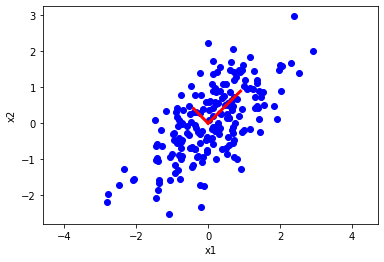

In [5]:
# Solution

# 1. compute covariance matrix
cov = np.cov(X, rowvar=0)

# 2. compute eigenvalue decomposition and sort eigenvalues if necessary
s, u = np.linalg.eig(cov)
idx =  np.argsort(s)[::-1]
u = u[:,idx]  
s = s[idx]

# 3. plot data
plt.scatter(X[:, 0], X[:, 1], c='b')

# 4. plot PCs
for i in range(u.shape[1]):
    plt.plot([0, u[0, i] * np.sqrt(s[i])], [0, u[1, i] * np.sqrt(s[i])], c='r', lw=3)
plt.axis('equal')
plt.xlabel('x1')
plt.ylabel('x2')

# 5. PC direction
# The PCs point into the direction of maximal variance, and are orthogonal to each other.

## Exercise 4: how outliers and scaling of the data affect PCA
The following dataset is similar to the one analyzed before, however it contains outliers. Explore the PCs again in the presence of outliers.
1. Like in exercise 2, compute and plot the PCs together with the scatter plot of the data;`
1. Why and how is PCA prone to fail in the presence of outliers?
1. How does the scaling of the features affect PCA? For example: Using cm instead of meters. **Hint:** PCA uses variance of the data as criterion to find the PCs.

In [6]:
X = np.loadtxt('data/PCA_2.data')
N_samples = X.shape[0]

In [7]:
# Answer here

Text(0, 0.5, 'x2')

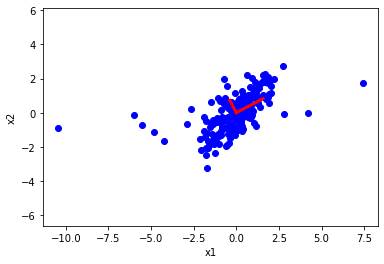

In [8]:
# Solution

# 1. compute eigenvalue decomposition of covariance matrix. Order eigenvalues if necessary
s, u = np.linalg.eig(np.cov(X, rowvar=0))
idx =  np.argsort(s)[::-1]
u = u[:, idx]  
s = s[idx]

# 1. plot data and PCs
plt.scatter(X[:, 0], X[:, 1], c='b')
for i in range(u.shape[1]):
    plt.plot([0, u[0, i] * np.sqrt(s[i])], [0, u[1, i] * np.sqrt(s[i])], c='r', lw=3)
plt.axis('equal')
plt.xlabel('x1')
plt.ylabel('x2')

# 2. outliers
# The criterion used by PCA to identified the most relevant components is based on the covariance 
# of the data. The presence of outliers in the data affects the sample variance/covariance of it, 
# thus deviating the identified components from the true relevant ones.

# 3. scaling
# Scaling of a variable is directly reflected on the variance of a given variable. Given that the 
# criterion used by PCA is the variance of the variables to assess their contribution to the 
# projection, any variable with a variance distorted by scaling will dominate the identified PC.

## Exercise 5: dimensionality reduction with PCA as preprocessing for classification problems (1/2)
In the following exercise, we will see how PCA can be used to reduce the dimensionality of a dataset as a pre-processing stage for a classification task.
1. For this dataset, plot the PCs together with the scatter plot of the labelled data like in exercise 3. Now, becuase we have labeled data of two classes, set the color of each of the points according to its class;
1. Project the data onto each of the PCs and plot the projection (e.g. as histogram);
1. Which of the PCs is more adequate to perform dimensionality reduction in the labelled dataset?

In [9]:
X = np.loadtxt('data/PCA_3.data')
y = np.loadtxt('data/PCA_3.labels')
N_samples = X.shape[0]

In [10]:
# Answer here

Text(0.5, 1.0, 'Projection on the second PC')

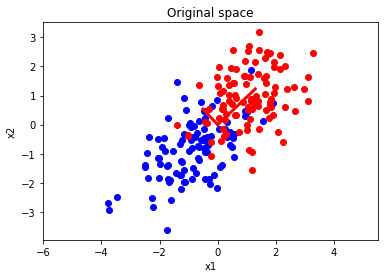

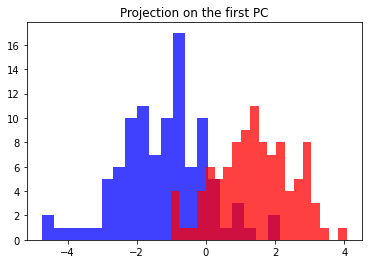

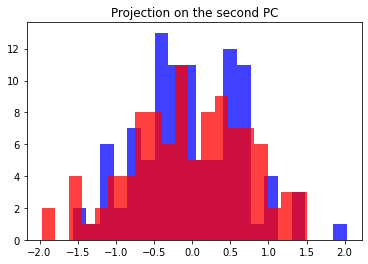

In [11]:
# Solution

# 1. compute eigenvalue decomposition of covariance matrix. Order eigenvalues if necessary
s, u = np.linalg.eig(np.cov(X, rowvar=0))
idx =  np.argsort(s)[::-1]
u = u[:, idx]  
s = s[idx]

# 1. plot original data
plt.figure()
plt.scatter(X[y==0, 0], X[y==0, 1],c='b')
plt.scatter(X[y==1, 0], X[y==1, 1],c='r')
for i in range(u.shape[1]):
    plt.plot([0, u[0, i] * np.sqrt(s[i])], [0, u[1, i] * np.sqrt(s[i])], c='r', lw=3)
plt.axis('equal')
plt.title('Original space')
plt.xlabel('x1')
plt.ylabel('x2')

# 2. plot data projection (first eigenvector)
X_proj = np.dot(X, u[:, 0])
plt.figure()
plt.hist(X_proj[y==0], 20, facecolor='b', alpha=0.75)
plt.hist(X_proj[y==1], 20, facecolor='r', alpha=0.75)
plt.title('Projection on the first PC')

# 2. plot data projection (second eigenvector)
X_proj = np.dot(X, u[:,1])
plt.figure()
plt.hist(X_proj[y==0], 20, facecolor='b', alpha=0.75)
plt.hist(X_proj[y==1], 20, facecolor='r', alpha=0.75)
plt.title('Projection on the second PC')

# 3. dimensionality reduction
# In this case, the first PC (the most relevant PC according to the eigenvalue criterion) 
# provides the best separability of the two classes.

## Exercise 6: dimensionality reduction with PCA as preprocessing for classification problems (2/2)
This exercise is similar to exercise 5, but with a different dataset. For questions 1. and 2., re-use the same code as previously.
1. For this dataset, plot the PCs together with the scatter plot of the labelled data like in exercise 3. Set the color of each of the points according to its class;
1. Project the data onto each of the PCs and plot the projection (e.g. as histogram);
1. What is the most relevant PC in this case, given that the goal is to perform dimensionality reduction for a classification task? Please, also compare your answer to exercise 4.

In [12]:
X = np.loadtxt('data/PCA_4.data')
y = np.loadtxt('data/PCA_4.labels')
N_samples = X.shape[0]

In [13]:
# Answer here

Text(0.5, 1.0, 'Projection on the second PC')

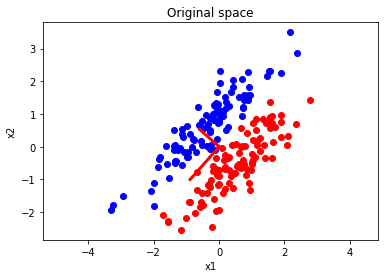

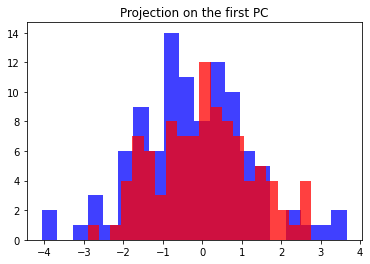

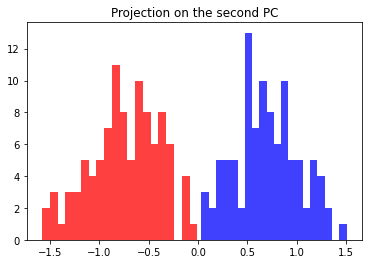

In [14]:
# Solution

# 1. compute eigenvalue decomposition of covariance matrix. Order eigenvalues if necessary
s, u = np.linalg.eig(np.cov(X, rowvar=0))
idx =  np.argsort(s)[::-1]
u = u[:, idx]  
s = s[idx]

# 1. plot original data
plt.figure()
plt.scatter(X[y==0, 0], X[y==0, 1],c='b')
plt.scatter(X[y==1, 0], X[y==1, 1],c='r')
for i in range(u.shape[1]):
    plt.plot([0, u[0, i] * np.sqrt(s[i])], [0, u[1, i] * np.sqrt(s[i])], c='r', lw=3)
plt.axis('equal')
plt.title('Original space')
plt.xlabel('x1')
plt.ylabel('x2')

# 2. plot data projection (first eigenvector)
X_proj = np.dot(X, u[:, 0])
plt.figure()
plt.hist(X_proj[y==0], 20, facecolor='b', alpha=0.75)
plt.hist(X_proj[y==1], 20, facecolor='r', alpha=0.75)
plt.title('Projection on the first PC')

# 2. plot data projection (second eigenvector)
X_proj = np.dot(X, u[:,1])
plt.figure()
plt.hist(X_proj[y==0], 20, facecolor='b', alpha=0.75)
plt.hist(X_proj[y==1], 20, facecolor='r', alpha=0.75)
plt.title('Projection on the second PC')

# 3.
# In this case, the projection onto the second most relevant component is the one providing the best 
# separability between both classes. Given that PCA is an unsupervised technique -it does not use 
# the information provided by the labels-, the PCs do not contain information about class-separability. 
# Instead, it provides only information about the best way to represent the variance in the data, 
# without regard to their labels.

## Exercise 7: PCA for dimensionality reduction: Selecting the number of PC in a high dimensional dataset
In this exercise, we will explore the criteria that might be used to select the number of components for a dimensionality reduction task using PCA.
1. Compute the PCs;
1. Plot the eigenvalue spectrum (e.g., using the `plt.stem()` function);
1. By visually inspecting the eigenvalue spectrum of the covariance matrix, how many components do you think are necessary to achieve a good representation of the variance of the data? **Hint:** The magnitude of the eigenvalues represents the contribution of the corresponding PC to the variance of the data.


In [15]:
X = np.loadtxt('data/PCA_5.data')
N_samples = X.shape[0]

In [16]:
# Answer here

Text(0, 0.5, 'explained variance')

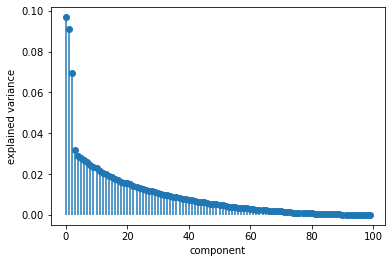

In [17]:
# Solution

# 1. compute eigenvalue decomposition of covariance matrix. Order eigenvalues if necessary
s, u = np.linalg.eig(np.cov(X, rowvar=0))
idx =  np.argsort(s)[::-1]
u = u[:, idx]  
s = s[idx]

# 2. plot eigenvalue spectrum
plt.figure()
markerline, stemlines, baseline = plt.stem(s / sum(s))
plt.setp(baseline, visible=False)
plt.xlabel('component')
plt.ylabel('explained variance')

# 3. number of components
# It can be observed that approximately 3 eigenvalues are clearly greater than the rest of the 
# spectrum. Therefore, it might be say that -in this case- around 3 PC might be enough to 
# achieve a good representation of the original data.


## Exercise 8: PCA for dimensionality reduction: Selecting the number of PC in a high dimensional dataset
Visually inspecting the eigenvalue spectrum of the covariance matrix does not always provide a clear criterion for the selection of the number of relevant components (i.e., it is subjective). If that is the case, an alternative criterion might be used: Typically, the number of PC is selected so as to achieve approximately 90% of accumulated variance. 
**Note:** This this is only a rule of thumb, values of 95% or 99% are also often seen.

1. (Optional) Using the cumulative variance criterion, how many components should be selected for performing dimensionality reduction in the following dataset? **Hint:** The eigenvalues represent the variance explained by the corresponding PC.

In [18]:
X = np.loadtxt('data/PCA_6.data')
N_samples = X.shape[0]

In [19]:
# Answer here

components needed:  47


/var/folders/ys/p6hy1z111t3_z17dpgg0fqwr0000gp/T/ipykernel_51867/1528192089.py:25: MatplotlibDeprecationWarning: Passing the linefmt parameter positionally is deprecated since Matplotlib 3.5; the parameter will become keyword-only two minor releases later.
  markerline, stemlines, baseline = plt.stem([n_components], [s[n_components] / sum(s)], 'r')


Text(0.5, 0, 'component')

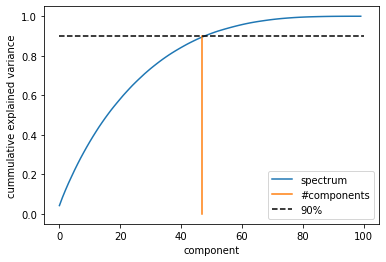

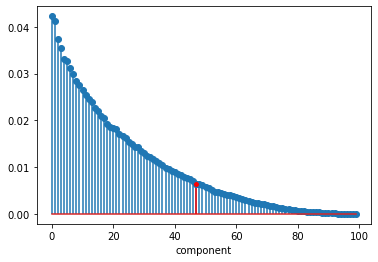

In [20]:
# Solution

# 1. compute eigenvalue decomposition of covariance matrix. Order eigenvalues if necessary
s,u = np.linalg.eig(np.cov(X,rowvar=0))
idx =  np.argsort(s)[::-1]
u = u[:,idx]  
s = s[idx]

# 1. find the number of components to reach 90% explained variance
n_components = np.where(np.diff((np.cumsum(s) / np.sum(s) >= 0.9).astype(int)))[0][0]
print("components needed: ", n_components)

# 1. plot cummulative eigenvalue spectrum
plt.figure()
plt.plot(np.cumsum(s) / np.sum(s), label="spectrum")
plt.plot([n_components, n_components], [0, 0.9], label="#components")
plt.plot([0, s.size], [0.9, 0.9], 'k--', label="90%")
plt.legend()
plt.xlabel('component')
plt.ylabel('cummulative explained variance')

# 1. plot eigenvalue spectrum
plt.figure()
plt.stem(s / sum(s))
markerline, stemlines, baseline = plt.stem([n_components], [s[n_components] / sum(s)], 'r')
plt.setp(markerline, 'markerfacecolor', 'r')
plt.xlabel('component')

# 2. number of components
# Using the 90% cumulative variance criterion, we would select approximately 50 components.

## Exercise 0: Who did what?
Please provide a short description on who contributed what to your submission.

> Answer here